In [1]:
import torch
from pathlib import Path
from models import SmallCnn,resnet18_model
import numpy as np
import pandas as pd
from collections import defaultdict

from utils import (
run_one_epoch,
set_seed,
evaluate_model,
calculate_classification_metrics,
plot_confusion_matrices,
print_metrics,
extract_predictions_and_confidence
)
from torchvision.models import resnet18,ResNet18_Weights

from datasets import val_loader,val_loader_resnet,val_dataset_resnet
from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


#### train baseline with CE,dropout=0.0

In [2]:
# ==============================================
# use the best model we saved and get metrics.
# ==============================================
set_seed(42)
model_best = SmallCnn(
    num_classes=8,
    dropout=0
).to(device)
state_dict = torch.load("../results/saved/best_baseline_small_cnn_0.0.pt")
model_best.load_state_dict(state_dict)
model_best.eval()
best_val_metrics = run_one_epoch(
    model_best,
    val_loader,
    optimizer=None,
    device=device
)
print(best_val_metrics)

{'loss': 0.2765516275589798, 'Accuracy': 0.9331550802139037}


In [3]:
y_true_base, y_pred_base = evaluate_model(
    model_best,
    val_loader,
    device=device
)

print(len(y_true_base))
print(len(y_pred_base))
print(y_true_base[:10])
print(y_pred_base[:10])

748
748
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[7, 0, 0, 5, 5, 0, 0, 0, 0, 0]


In [4]:
classes = ['ambulance','autobus','kamyun','kamyunet','minibus','savari','taxi','vanet']

metrics_base = calculate_classification_metrics(y_true_base, y_pred_base)

print_metrics(metrics_base,classes)


Precision macro: 0.9367
Recall macro: 0.9152
F1 macro: 0.9229

Per-class metrics:
ambulance  | Precision: 1.00 | Recall: 0.95 | F1: 0.97
autobus    | Precision: 0.94 | Recall: 0.99 | F1: 0.96
kamyun     | Precision: 0.96 | Recall: 0.82 | F1: 0.88
kamyunet   | Precision: 0.84 | Recall: 0.98 | F1: 0.91
minibus    | Precision: 1.00 | Recall: 0.90 | F1: 0.95
savari     | Precision: 0.90 | Recall: 0.97 | F1: 0.94
taxi       | Precision: 0.97 | Recall: 0.98 | F1: 0.98
vanet      | Precision: 0.88 | Recall: 0.72 | F1: 0.79


In [5]:
cm_base = confusion_matrix(y_true_base,y_pred_base)
print(cm_base)
cm_base.shape

[[ 77   0   0   0   0   3   0   1]
 [  0 103   0   0   0   0   1   0]
 [  0   2  80  13   0   1   1   1]
 [  0   2   0 111   0   0   0   0]
 [  0   2   3   4  83   0   0   0]
 [  0   0   0   0   0 110   1   2]
 [  0   0   0   2   0   0 105   0]
 [  0   1   0   2   0   8   0  29]]


(8, 8)

In [6]:
cm_normalized_base = cm_base / cm_base.sum(axis=1, keepdims=True)
print(cm_normalized_base)
# قطر اصلی ماتریس همان recall هر کلاس است

[[0.95061728 0.         0.         0.         0.         0.03703704
  0.         0.01234568]
 [0.         0.99038462 0.         0.         0.         0.
  0.00961538 0.        ]
 [0.         0.02040816 0.81632653 0.13265306 0.         0.01020408
  0.01020408 0.01020408]
 [0.         0.01769912 0.         0.98230088 0.         0.
  0.         0.        ]
 [0.         0.02173913 0.0326087  0.04347826 0.90217391 0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.97345133
  0.00884956 0.01769912]
 [0.         0.         0.         0.01869159 0.         0.
  0.98130841 0.        ]
 [0.         0.025      0.         0.05       0.         0.2
  0.         0.725     ]]


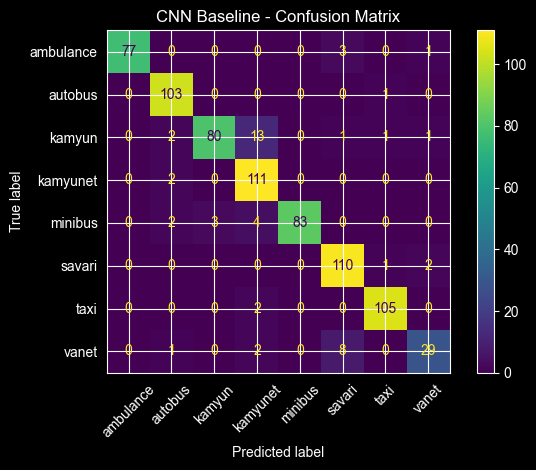

In [7]:
output_dir = Path("../results/img")
output_dir.mkdir(parents=True, exist_ok=True)

cmd = ConfusionMatrixDisplay(
    confusion_matrix=cm_base,
    display_labels=classes
)
cmd.plot(xticks_rotation=45)
plt.title("CNN Baseline - Confusion Matrix")
plt.tight_layout()
plt.savefig(
    output_dir / "SmallCnn_base_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

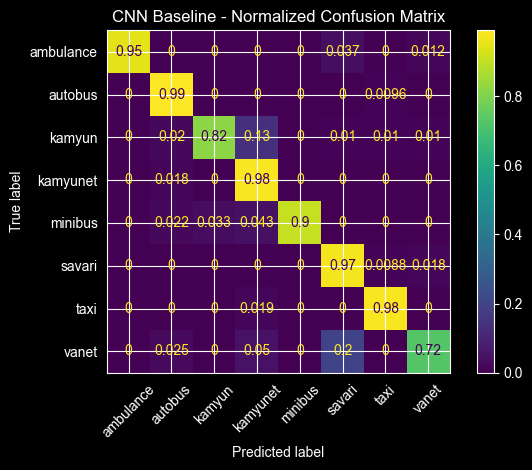

In [8]:
cmd = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized_base,
    display_labels=classes
)
cmd.plot(xticks_rotation=45)
plt.title("CNN Baseline - Normalized Confusion Matrix")
plt.tight_layout()
plt.savefig(
    output_dir / "SmallCnn_base_confusion_matrix_normalized.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

SmallCnn Augmented

In [9]:
model_aug_best = SmallCnn(
    num_classes=8,
    dropout=0
).to(device)

state_dict = torch.load(
    "../results/saved/best_augmented_small_cnn.pt",
    map_location=device
)

model_aug_best.load_state_dict(state_dict)

<All keys matched successfully>

In [10]:
y_true_aug, y_pred_aug = evaluate_model(
    model_aug_best,
    val_loader,
    device=device
)

In [11]:
metrics_aug = calculate_classification_metrics(y_true_aug, y_pred_aug)
print_metrics(metrics_aug,classes)


Precision macro: 0.9182
Recall macro: 0.9045
F1 macro: 0.9099

Per-class metrics:
ambulance  | Precision: 1.00 | Recall: 0.93 | F1: 0.96
autobus    | Precision: 0.97 | Recall: 0.93 | F1: 0.95
kamyun     | Precision: 0.89 | Recall: 0.87 | F1: 0.88
kamyunet   | Precision: 0.88 | Recall: 0.92 | F1: 0.90
minibus    | Precision: 0.86 | Recall: 0.96 | F1: 0.91
savari     | Precision: 0.89 | Recall: 0.96 | F1: 0.93
taxi       | Precision: 0.99 | Recall: 0.94 | F1: 0.97
vanet      | Precision: 0.85 | Recall: 0.72 | F1: 0.78


In [12]:
cm_aug = confusion_matrix(y_true_aug,y_pred_aug)
print(cm_aug)
cm_aug.shape

[[ 75   0   0   1   0   3   0   2]
 [  0  97   0   1   5   0   1   0]
 [  0   1  85   8   4   0   0   0]
 [  0   1   6 104   2   0   0   0]
 [  0   0   3   1  88   0   0   0]
 [  0   0   0   0   1 109   0   3]
 [  0   1   0   2   1   2 101   0]
 [  0   0   1   1   1   8   0  29]]


(8, 8)

In [13]:
cm_normalized_aug = cm_aug / cm_aug.sum(axis=1, keepdims=True)
print(cm_normalized_aug)


[[0.92592593 0.         0.         0.01234568 0.         0.03703704
  0.         0.02469136]
 [0.         0.93269231 0.         0.00961538 0.04807692 0.
  0.00961538 0.        ]
 [0.         0.01020408 0.86734694 0.08163265 0.04081633 0.
  0.         0.        ]
 [0.         0.00884956 0.05309735 0.92035398 0.01769912 0.
  0.         0.        ]
 [0.         0.         0.0326087  0.01086957 0.95652174 0.
  0.         0.        ]
 [0.         0.         0.         0.         0.00884956 0.96460177
  0.         0.02654867]
 [0.         0.00934579 0.         0.01869159 0.00934579 0.01869159
  0.94392523 0.        ]
 [0.         0.         0.025      0.025      0.025      0.2
  0.         0.725     ]]


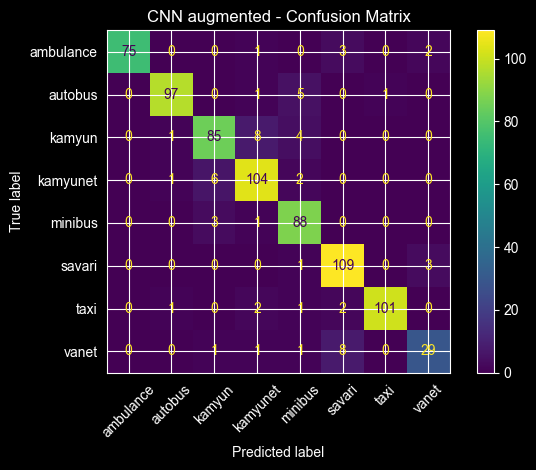

In [14]:
output_dir = Path("../results/img")
output_dir.mkdir(parents=True, exist_ok=True)

cmd = ConfusionMatrixDisplay(
    confusion_matrix=cm_aug,
    display_labels=classes
)
cmd.plot(xticks_rotation=45)
plt.title("CNN augmented - Confusion Matrix")
plt.tight_layout()
plt.savefig(
    output_dir / "SmallCnn_aug_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

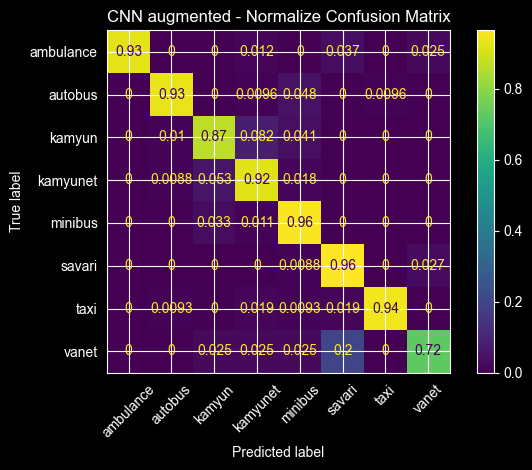

In [15]:
output_dir = Path("../results/img")
output_dir.mkdir(parents=True, exist_ok=True)

cmd = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized_aug,
    display_labels=classes
)
cmd.plot(xticks_rotation=45)
plt.title("CNN augmented - Normalize Confusion Matrix")
plt.tight_layout()
plt.savefig(
    output_dir / "SmallCnn_aug_confusion_matrix_normalized.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()


### small cnn with dropout [0.3, 0.5]


In [16]:
def evaluate_checkpoint(checkpoint_path, dropout, val_loader, device):
    model = SmallCnn(
        num_classes=8,
        dropout=dropout
    ).to(device)
    state_dict = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(state_dict)

    y_true , y_pred = evaluate_model(
        model,
        val_loader,
        device=device
    )
    cm_drop, cm_normalized_drop = plot_confusion_matrices(
    y_true=y_true,
    y_pred=y_pred,
    classes=classes,
    experiment_name=f"small_cnn_dropout_{dropout}",
    output_dir="../results/img"
)
    metrics = calculate_classification_metrics(y_true,y_pred)

    return metrics,cm_drop,cm_normalized_drop

In [17]:
checkpoint_dir = Path("../results/saved")

dropout_experiments = {
    "dropout_0.0": {
        "dropout": 0.0,
        "checkpoint": checkpoint_dir / "best_baseline_small_cnn_0.0.pt"
    },
    "dropout_0.3": {
        "dropout": 0.3,
        "checkpoint": checkpoint_dir / "best_baseline_small_cnn_0.3.pt"
    },
    "dropout_0.5": {
        "dropout": 0.5,
        "checkpoint": checkpoint_dir / "best_baseline_small_cnn_0.5.pt"
    }
}

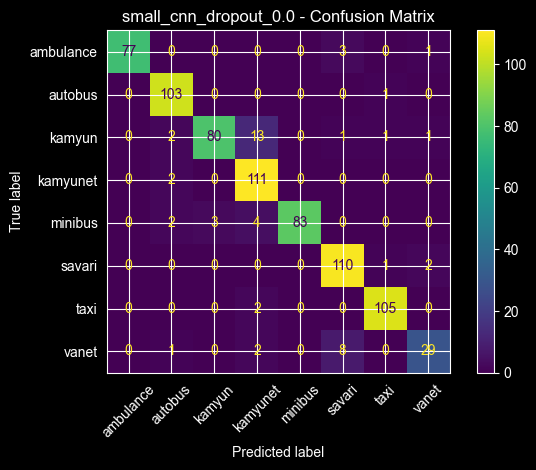

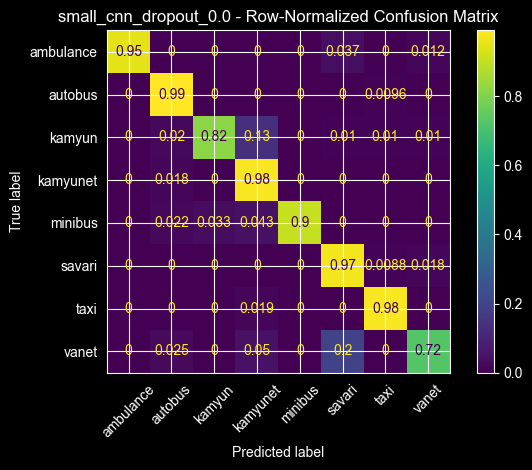

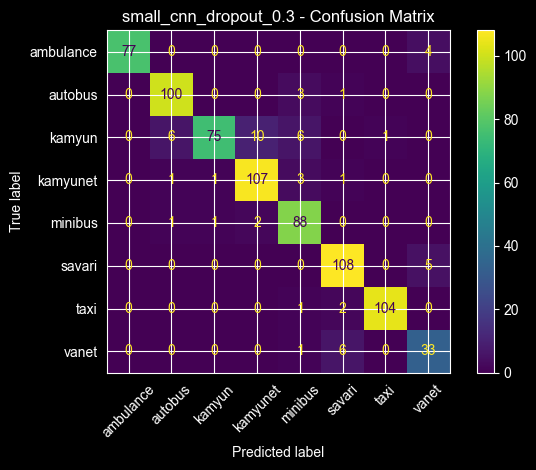

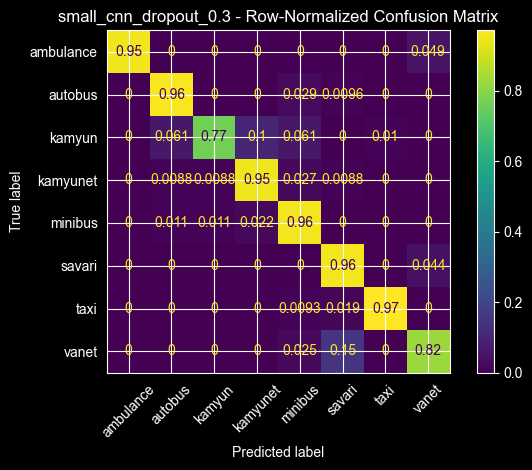

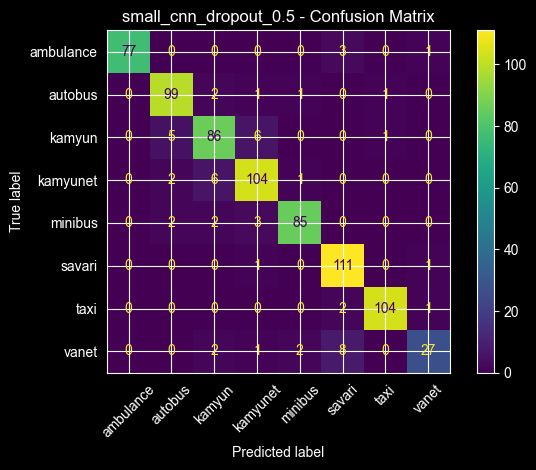

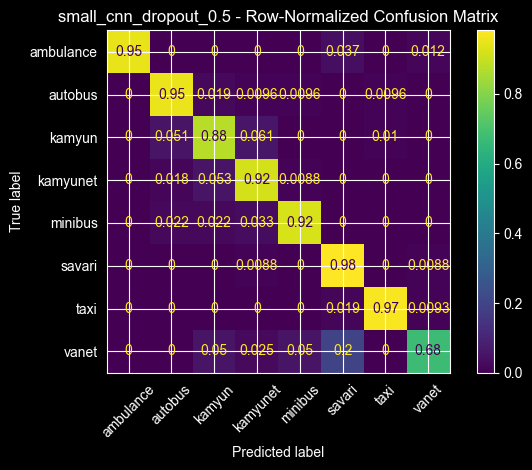

In [18]:
dropout_metrics = {}
cm_drop_dict = {}
for name, config in dropout_experiments.items():

    metrics,cm_drop,cm_normalized_drop = evaluate_checkpoint(
        checkpoint_path=config["checkpoint"],
        dropout=config["dropout"],
        val_loader=val_loader,
        device=device
    )

    dropout_metrics[name] = metrics
    cm_drop_dict[name] = [cm_drop,cm_normalized_drop]

In [19]:
print("\n=== Dropout Comparison ===")

print(
    f"{'Dropout':<10}"
    f"{'Precision':<12}"
    f"{'Recall':<12}"
    f"{'F1':<12}"
)

for name, metrics in dropout_metrics.items():

    dropout = name.replace("dropout_", "")

    print(
        f"{dropout:<10}"
        f"{metrics['precision_macro']:<12.4f}"
        f"{metrics['recall_macro']:<12.4f}"
        f"{metrics['f1_macro']:<12.5f}"
    )


=== Dropout Comparison ===
Dropout   Precision   Recall      F1          
0.0       0.9367      0.9152      0.92293     
0.3       0.9192      0.9167      0.91574     
0.5       0.9278      0.9067      0.91480     


In [20]:
for name, metrics in dropout_metrics.items():

    print(f"\n=== {name} - Per Class ===")
    print_metrics(metrics,classes)


=== dropout_0.0 - Per Class ===
Precision macro: 0.9367
Recall macro: 0.9152
F1 macro: 0.9229

Per-class metrics:
ambulance  | Precision: 1.00 | Recall: 0.95 | F1: 0.97
autobus    | Precision: 0.94 | Recall: 0.99 | F1: 0.96
kamyun     | Precision: 0.96 | Recall: 0.82 | F1: 0.88
kamyunet   | Precision: 0.84 | Recall: 0.98 | F1: 0.91
minibus    | Precision: 1.00 | Recall: 0.90 | F1: 0.95
savari     | Precision: 0.90 | Recall: 0.97 | F1: 0.94
taxi       | Precision: 0.97 | Recall: 0.98 | F1: 0.98
vanet      | Precision: 0.88 | Recall: 0.72 | F1: 0.79

=== dropout_0.3 - Per Class ===
Precision macro: 0.9192
Recall macro: 0.9167
F1 macro: 0.9157

Per-class metrics:
ambulance  | Precision: 1.00 | Recall: 0.95 | F1: 0.97
autobus    | Precision: 0.93 | Recall: 0.96 | F1: 0.94
kamyun     | Precision: 0.97 | Recall: 0.77 | F1: 0.86
kamyunet   | Precision: 0.90 | Recall: 0.95 | F1: 0.92
minibus    | Precision: 0.86 | Recall: 0.96 | F1: 0.91
savari     | Precision: 0.92 | Recall: 0.96 | F1: 0.94


### avgpool

In [21]:
model_avg_best = SmallCnn(
    num_classes=8,
    dropout=0.0,
    pooling="avg"
).to(device)

state_dict = torch.load(
    "../results/saved/best_small_cnn_avg_pool.pt",
    map_location=device
)

model_avg_best.load_state_dict(state_dict)
model_avg_best

SmallCnn(
  (conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (14): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): 

In [22]:
model_avg_best.eval()
best_avg_metrics = run_one_epoch(
    model_avg_best,
    val_loader,
    optimizer=None,
    device=device
)
print(best_avg_metrics)


{'loss': 0.33035976595100874, 'Accuracy': 0.9157754010695187}


In [23]:
y_true_avg, y_pred_avg = evaluate_model(
    model_avg_best,
    val_loader,
    device=device
)
avg_metrics = calculate_classification_metrics(
    y_true=y_true_avg,
    y_pred=y_pred_avg,
)


In [24]:
print_metrics(avg_metrics,classes)


Precision macro: 0.9238
Recall macro: 0.8907
F1 macro: 0.9005

Per-class metrics:
ambulance  | Precision: 0.94 | Recall: 0.96 | F1: 0.95
autobus    | Precision: 0.92 | Recall: 0.96 | F1: 0.94
kamyun     | Precision: 0.94 | Recall: 0.80 | F1: 0.86
kamyunet   | Precision: 0.85 | Recall: 0.94 | F1: 0.89
minibus    | Precision: 0.91 | Recall: 0.91 | F1: 0.91
savari     | Precision: 0.88 | Recall: 0.99 | F1: 0.93
taxi       | Precision: 0.99 | Recall: 0.96 | F1: 0.98
vanet      | Precision: 0.96 | Recall: 0.60 | F1: 0.74


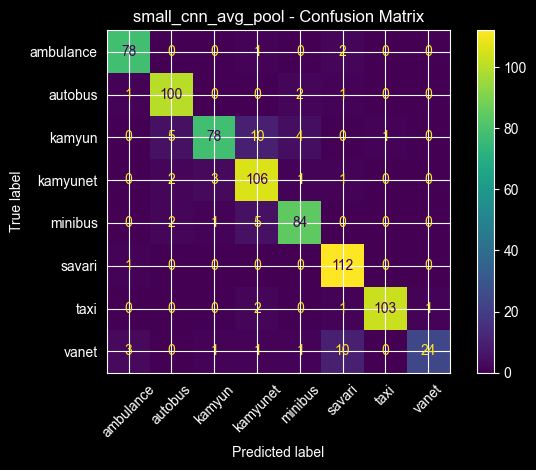

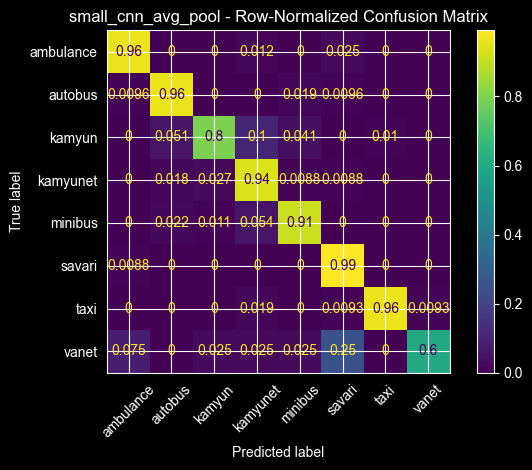

In [25]:
cm_avg, cm_normalized_avg = plot_confusion_matrices(
    y_true=y_true_avg,
    y_pred=y_pred_avg,
    classes=classes,
    experiment_name="small_cnn_avg_pool",
    output_dir="../results/img"
)

### weight decay

In [26]:
model_weight_decay_best = SmallCnn(
    num_classes=8,
    dropout=0,
    pooling="max"
).to(device)

state_dict = torch.load(
    "../results/saved/best_weight_decay_small_cnn_0.0001.pt",
    map_location=device
)

model_weight_decay_best.load_state_dict(state_dict)


model_weight_decay_best.eval()
best_weight_decay_metrics = run_one_epoch(
    model_weight_decay_best,
    val_loader,
    optimizer=None,
    device=device
)
print(best_weight_decay_metrics)

{'loss': 0.2426450484417339, 'Accuracy': 0.9344919786096256}


In [27]:
y_true_wd , y_pred_wd = evaluate_model(
    model_weight_decay_best,
    val_loader,
    device=device
)
len(y_true_wd)

748

In [28]:
wd_metrics = calculate_classification_metrics(
    y_true_wd,
    y_pred_wd
)
print_metrics(wd_metrics, classes)

Precision macro: 0.9350
Recall macro: 0.9210
F1 macro: 0.9268

Per-class metrics:
ambulance  | Precision: 1.00 | Recall: 0.95 | F1: 0.97
autobus    | Precision: 0.95 | Recall: 0.93 | F1: 0.94
kamyun     | Precision: 0.91 | Recall: 0.88 | F1: 0.90
kamyunet   | Precision: 0.92 | Recall: 0.96 | F1: 0.94
minibus    | Precision: 0.95 | Recall: 0.91 | F1: 0.93
savari     | Precision: 0.87 | Recall: 0.99 | F1: 0.93
taxi       | Precision: 0.99 | Recall: 0.97 | F1: 0.98
vanet      | Precision: 0.89 | Recall: 0.78 | F1: 0.83


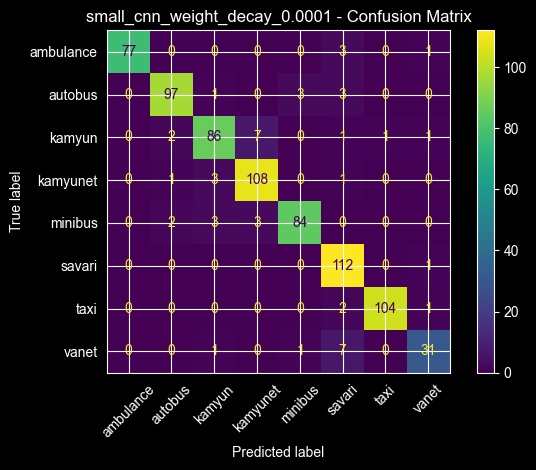

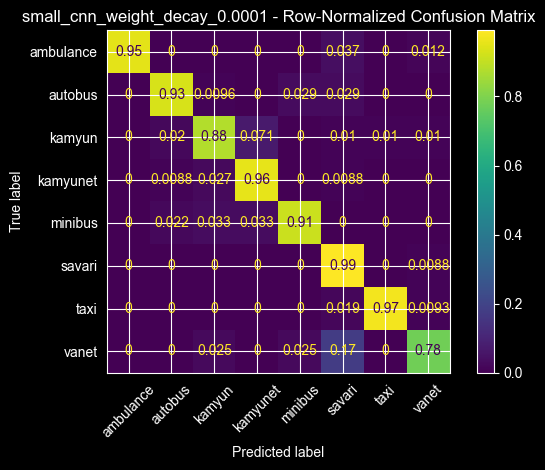

In [29]:
cm_wd, cm_normalized_wd = plot_confusion_matrices(
    y_true=y_true_wd,
    y_pred=y_pred_wd,
    classes=classes,
    experiment_name="small_cnn_weight_decay_0.0001",
    output_dir="../results/img"
)

#### StepLR

In [30]:
model_lr = SmallCnn(
    num_classes=8,
    dropout=0,
    pooling="max"
).to(device)
state_dict = torch.load("../results/saved/best_small_cnn_step_lr.pt")
model_lr.load_state_dict(state_dict)
model_lr.eval()
best_lr_metrics = run_one_epoch(
    model_lr,
    val_loader,
    device=device
)
print(best_lr_metrics)

{'loss': 0.32437243053619874, 'Accuracy': 0.9077540106951871}


In [31]:
y_true_lr, y_pred_lr = evaluate_model(
    model_lr,
    val_loader,
    device=device
)
len(y_true_lr)

748

In [32]:
lr_metrics = calculate_classification_metrics(
    y_true_lr,
    y_pred_lr
)
print_metrics(lr_metrics, classes)

Precision macro: 0.9041
Recall macro: 0.8775
F1 macro: 0.8858

Per-class metrics:
ambulance  | Precision: 0.97 | Recall: 0.95 | F1: 0.96
autobus    | Precision: 0.90 | Recall: 0.91 | F1: 0.91
kamyun     | Precision: 0.90 | Recall: 0.85 | F1: 0.87
kamyunet   | Precision: 0.90 | Recall: 0.92 | F1: 0.91
minibus    | Precision: 0.93 | Recall: 0.89 | F1: 0.91
savari     | Precision: 0.82 | Recall: 1.00 | F1: 0.90
taxi       | Precision: 0.99 | Recall: 0.97 | F1: 0.98
vanet      | Precision: 0.81 | Recall: 0.53 | F1: 0.64


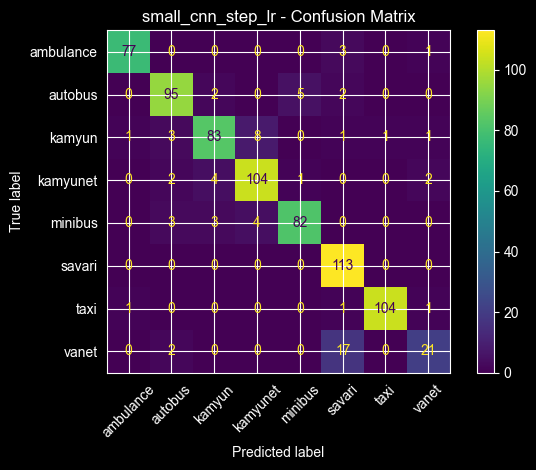

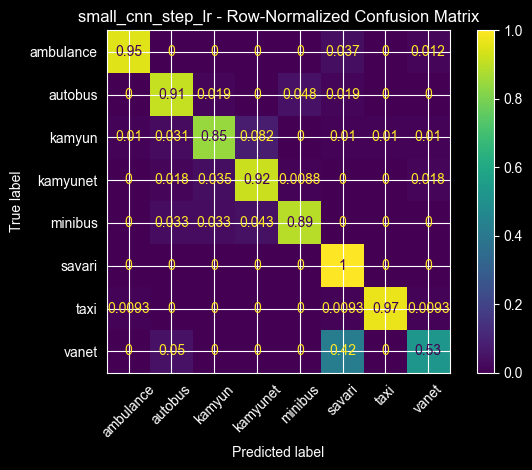

In [33]:
cm_lr, cm_normalized_lr = plot_confusion_matrices(
    y_true=y_true_lr,
    y_pred=y_pred_lr,
    classes=classes,
    experiment_name="small_cnn_step_lr",
    output_dir="../results/img"
)

### ReduceLROnPlateau

In [34]:
model_lrp = SmallCnn(
    num_classes=8,
    dropout=0,
    pooling="max",
).to(device)
state_dict = torch.load("../results/saved/best_reduce_lr_small_cnn.pt")
model_lrp.load_state_dict(state_dict)
model_lrp.eval()
best_lrp_metrics = run_one_epoch(
    model_lrp,
    val_loader,
    device=device,
)
best_lrp_metrics

{'loss': 0.25043500967841736, 'Accuracy': 0.9251336898395722}

In [35]:
y_true_rlr, y_pred_rlr = evaluate_model(
    model_lrp,
    val_loader,
    device=device
)
len(y_true_rlr)

748

In [36]:
rlr_metrics = calculate_classification_metrics(
    y_true_rlr,
    y_pred_rlr
)
print_metrics(rlr_metrics, classes)


Precision macro: 0.9161
Recall macro: 0.9018
F1 macro: 0.9072

Per-class metrics:
ambulance  | Precision: 1.00 | Recall: 0.96 | F1: 0.98
autobus    | Precision: 0.96 | Recall: 0.92 | F1: 0.94
kamyun     | Precision: 0.90 | Recall: 0.87 | F1: 0.89
kamyunet   | Precision: 0.92 | Recall: 0.94 | F1: 0.93
minibus    | Precision: 0.90 | Recall: 0.93 | F1: 0.91
savari     | Precision: 0.88 | Recall: 0.99 | F1: 0.93
taxi       | Precision: 0.99 | Recall: 0.97 | F1: 0.98
vanet      | Precision: 0.78 | Recall: 0.62 | F1: 0.69


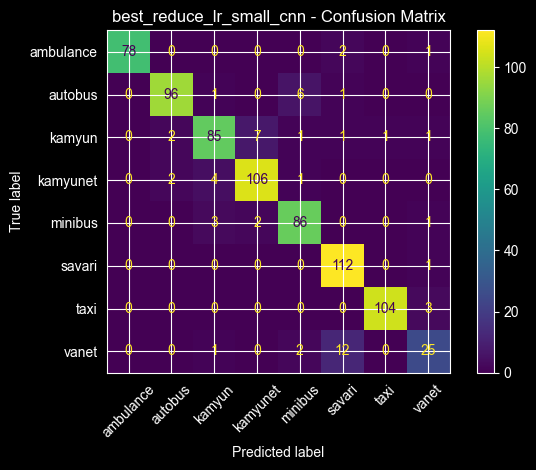

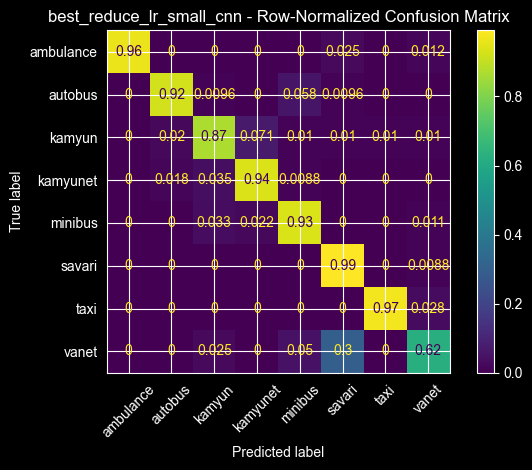

In [37]:
cm_rlr, cm_normalized_rlr = plot_confusion_matrices(
    y_true=y_true_rlr,
    y_pred=y_pred_rlr,
    classes=classes,
    experiment_name="best_reduce_lr_small_cnn",
    output_dir="../results/img"
)

### Imbalanced datasets

In [38]:
model_standard = SmallCnn(
    num_classes=8,
    dropout=0,
    pooling="max",
).to(device)
state_dict = torch.load("../results/saved/train_loader_standard_imbalanced.pt")
model_standard.load_state_dict(state_dict)
model_standard.eval()
best_standard_metrics = run_one_epoch(
    model_standard,
    val_loader,
    device=device,
)
best_standard_metrics

{'loss': 0.35557793009089916, 'Accuracy': 0.8957219251336899}

In [39]:
y_true_standard, y_pred_standard = evaluate_model(
    model_standard,
    val_loader,
    device=device
)
len(y_true_standard)

748

In [40]:
standard_metrics = calculate_classification_metrics(
    y_true_standard,
    y_pred_standard
)
print_metrics(standard_metrics, classes)

Precision macro: 0.8825
Recall macro: 0.8831
F1 macro: 0.8809

Per-class metrics:
ambulance  | Precision: 0.97 | Recall: 0.89 | F1: 0.93
autobus    | Precision: 0.93 | Recall: 0.85 | F1: 0.88
kamyun     | Precision: 0.93 | Recall: 0.82 | F1: 0.87
kamyunet   | Precision: 0.90 | Recall: 0.92 | F1: 0.91
minibus    | Precision: 0.82 | Recall: 0.92 | F1: 0.87
savari     | Precision: 0.88 | Recall: 0.95 | F1: 0.91
taxi       | Precision: 0.97 | Recall: 0.97 | F1: 0.97
vanet      | Precision: 0.65 | Recall: 0.75 | F1: 0.70


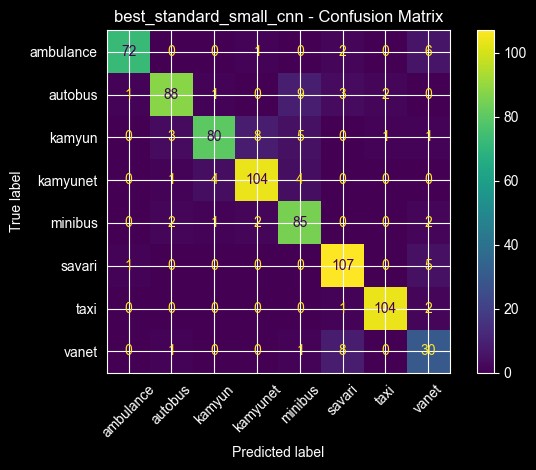

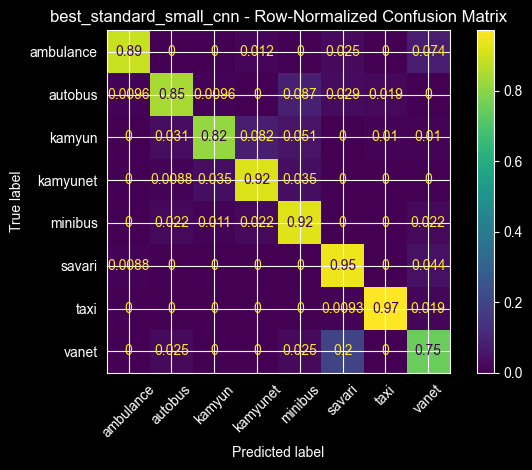

In [41]:
cm_standard, cm_normalized_standard = plot_confusion_matrices(
    y_true=y_true_standard,
    y_pred=y_pred_standard,
    classes=classes,
    experiment_name="best_standard_small_cnn",
    output_dir="../results/img"
)

In [42]:
model_balanced = SmallCnn(
    num_classes=8,
    dropout=0,
    pooling="max",
).to(device)
state_dict = torch.load("../results/saved/train_balanced_imbalanced.pt")
model_balanced.load_state_dict(state_dict)
model_balanced.eval()
best_balanced_metrics = run_one_epoch(
    model_balanced,
    val_loader,
    device=device,
)
best_balanced_metrics

{'loss': 0.4563566578582009, 'Accuracy': 0.8850267379679144}

In [43]:
y_true_balanced, y_pred_balanced = evaluate_model(
    model_balanced,
    val_loader,
    device=device
)
len(y_true_balanced)

748

In [44]:
balanced_metrics = calculate_classification_metrics(
    y_true_balanced,
    y_pred_balanced
)
print_metrics(balanced_metrics, classes)


Precision macro: 0.8702
Recall macro: 0.8750
F1 macro: 0.8718

Per-class metrics:
ambulance  | Precision: 0.91 | Recall: 0.91 | F1: 0.91
autobus    | Precision: 0.88 | Recall: 0.88 | F1: 0.88
kamyun     | Precision: 0.83 | Recall: 0.81 | F1: 0.82
kamyunet   | Precision: 0.88 | Recall: 0.88 | F1: 0.88
minibus    | Precision: 0.90 | Recall: 0.83 | F1: 0.86
savari     | Precision: 0.91 | Recall: 0.95 | F1: 0.93
taxi       | Precision: 0.96 | Recall: 0.97 | F1: 0.97
vanet      | Precision: 0.67 | Recall: 0.78 | F1: 0.72


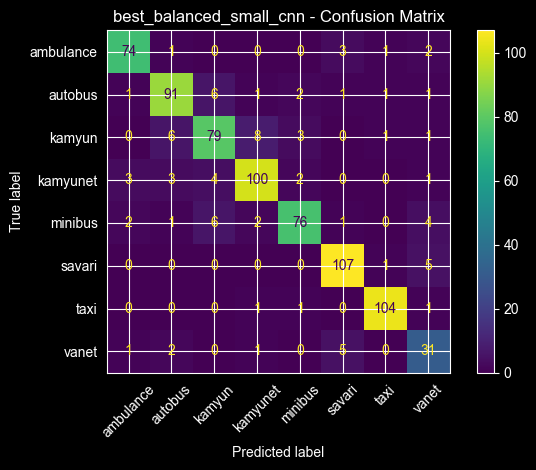

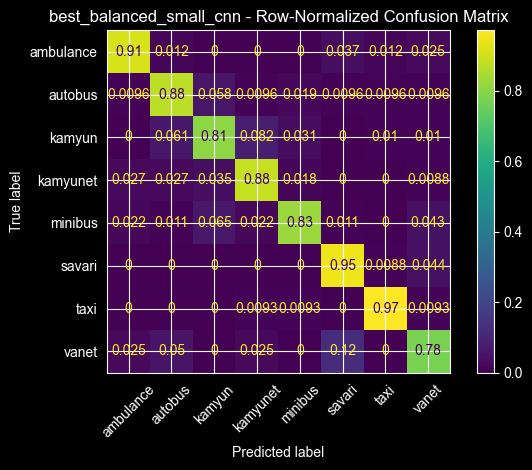

In [45]:
cm_balanced, cm_normalized_balanced = plot_confusion_matrices(
    y_true=y_true_balanced,
    y_pred=y_pred_balanced,
    classes=classes,
    experiment_name="best_balanced_small_cnn",
    output_dir="../results/img"
)

## train baseline with BCE

In [46]:
model_bce_best = SmallCnn(
    num_classes=8,
    dropout=0,
    pooling="max"
).to(device)

state_dict = torch.load(
    "../results/saved/best_bce_small_cnn.pt",
    map_location=device
)

model_bce_best.load_state_dict(state_dict)

y_true_bce, y_pred_bce = evaluate_model(
    model_bce_best,
    val_loader,
    device=device
)

metrics_bce = calculate_classification_metrics(
    y_true_bce,
    y_pred_bce
)
print_metrics(metrics_bce,classes)

Precision macro: 0.9310
Recall macro: 0.9245
F1 macro: 0.9265

Per-class metrics:
ambulance  | Precision: 1.00 | Recall: 0.89 | F1: 0.94
autobus    | Precision: 0.92 | Recall: 0.96 | F1: 0.94
kamyun     | Precision: 0.93 | Recall: 0.87 | F1: 0.90
kamyunet   | Precision: 0.90 | Recall: 0.98 | F1: 0.94
minibus    | Precision: 0.98 | Recall: 0.89 | F1: 0.93
savari     | Precision: 0.93 | Recall: 0.98 | F1: 0.96
taxi       | Precision: 0.96 | Recall: 0.97 | F1: 0.97
vanet      | Precision: 0.83 | Recall: 0.85 | F1: 0.84


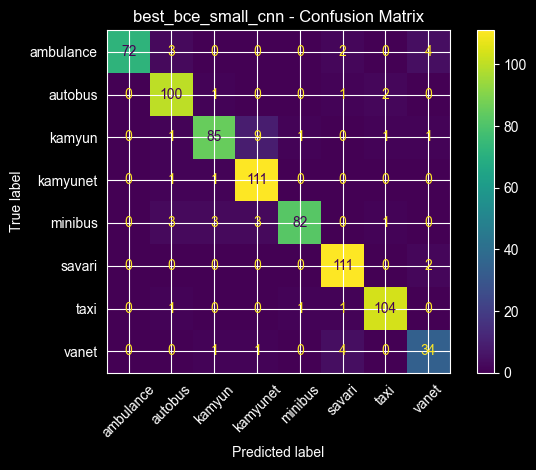

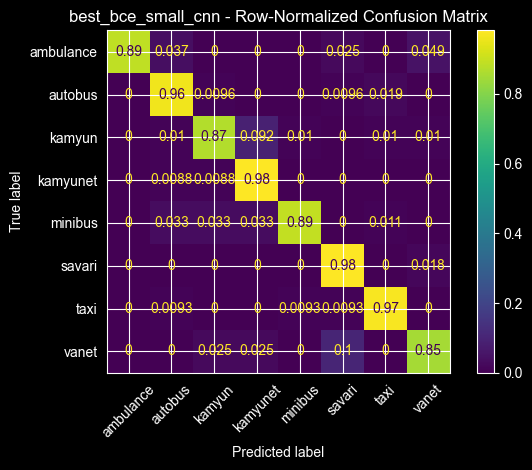

In [47]:
cm_bce, cm_normalized_bce = plot_confusion_matrices(
    y_true=y_true_bce,
    y_pred=y_pred_bce,
    classes=classes,
    experiment_name="best_bce_small_cnn",
    output_dir="../results/img"
)

#### predictions_and_confidence for CE and BCE

In [48]:
y_true_ce, y_pred_ce, conf_ce, scores_ce = extract_predictions_and_confidence(
    model_best,
    val_loader,
    device=device,
    loss_type="ce"
)
y_true_bce, y_pred_bce, conf_bce, scores_bce = (
    extract_predictions_and_confidence(
        model_bce_best,
        val_loader,
        device,
        loss_type="bce"
    )
)


In [49]:
print("CE")
print("mean  :", np.mean(conf_ce))
print("median:", np.median(conf_ce))
print("min   :", np.min(conf_ce))
print("max   :", np.max(conf_ce))

print("\nBCE")
print("mean  :", np.mean(conf_bce))
print("median:", np.median(conf_bce))
print("min   :", np.min(conf_bce))
print("max   :", np.max(conf_bce))
# مدل CE معمولاً predictionهایش را با اطمینان بیشتری بیان می‌کند.

CE
mean  : 0.95442176
median: 0.9994387
min   : 0.32304204
max   : 1.0

BCE
mean  : 0.9019212
median: 0.9961903
min   : 0.0045053526
max   : 1.0


In [50]:
correct_ce = np.array(conf_ce)[
    np.array(y_true_ce) == np.array(y_pred_ce)
]

wrong_ce = np.array(conf_ce)[
    np.array(y_true_ce) != np.array(y_pred_ce)
]

correct_bce = np.array(conf_bce)[
    np.array(y_true_bce) == np.array(y_pred_bce)
]

wrong_bce = np.array(conf_bce)[
    np.array(y_true_bce) != np.array(y_pred_bce)
]
print("CE")
print("correct mean:", correct_ce.mean())
print("wrong mean  :", wrong_ce.mean())

print("\nBCE")
print("correct mean:", correct_bce.mean())
print("wrong mean  :", wrong_bce.mean())
# CE حتی وقتی اشتباه می‌کند، confidence آن هنوز نسبتاً بالا است.

CE
correct mean: 0.96798056
wrong mean  : 0.76513934

BCE
correct mean: 0.9271509
wrong mean  : 0.5420123


<div dir=rtl>BCE از نظر classification performance ضعیف‌تر بود، اما در این آزمایش روی خطاهایش کمتر با اطمینان بالا عمل کرده است.</div>

#### ResNet18 pretrained

In [51]:
best_resnet_model = resnet18_model(
    num_classes=8
).to(device)
state_dict = torch.load(
    "../results/saved/resnet18_pretrained.pt",
    map_location=device
)
best_resnet_model.load_state_dict(state_dict)
best_resnet_model.eval()
y_true_res_pre , y_pred_res_pre = evaluate_model(
    best_resnet_model,
    val_loader_resnet,
    device=device
)
res_pre_metrics = calculate_classification_metrics(
    y_true_res_pre,
    y_pred_res_pre
)

In [52]:
print_metrics(res_pre_metrics,classes)

Precision macro: 0.9124
Recall macro: 0.8970
F1 macro: 0.9032

Per-class metrics:
ambulance  | Precision: 0.96 | Recall: 0.94 | F1: 0.95
autobus    | Precision: 0.95 | Recall: 0.93 | F1: 0.94
kamyun     | Precision: 0.79 | Recall: 0.85 | F1: 0.82
kamyunet   | Precision: 0.86 | Recall: 0.85 | F1: 0.86
minibus    | Precision: 0.95 | Recall: 0.96 | F1: 0.95
savari     | Precision: 0.92 | Recall: 0.96 | F1: 0.94
taxi       | Precision: 0.96 | Recall: 0.96 | F1: 0.96
vanet      | Precision: 0.91 | Recall: 0.72 | F1: 0.81


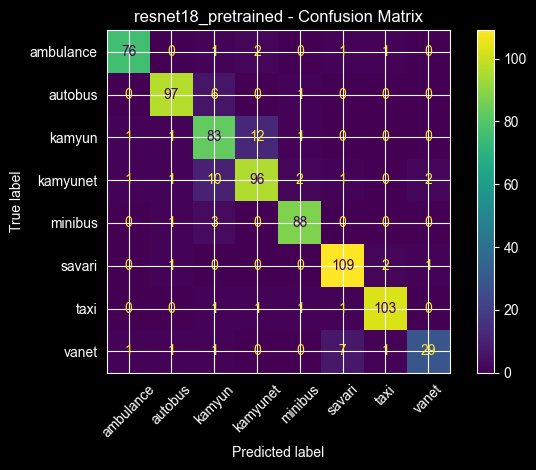

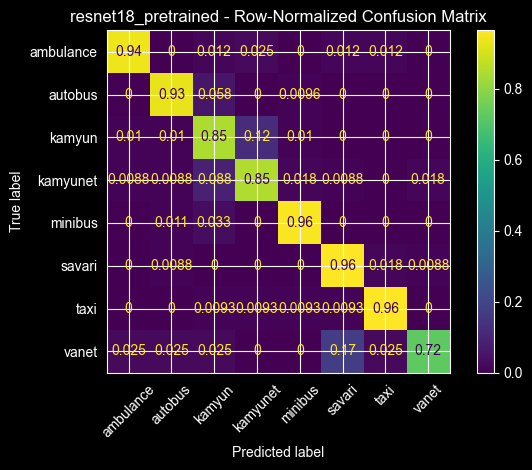

In [53]:
cm_res_pre , cm_res_normalized_pre = plot_confusion_matrices(
    y_true_res_pre,
    y_pred_res_pre,
    classes=classes,
    experiment_name="resnet18_pretrained",
    output_dir="../results/img",
)

#### ResNet18 fine-tuned

In [54]:
model_resnet_ft = resnet18_model(
    num_classes=8
).to(device)
for param in model_resnet_ft.parameters():
    param.requires_grad = False

for param in model_resnet_ft.layer4.parameters():
    param.requires_grad = True

for param in model_resnet_ft.fc.parameters():
    param.requires_grad = True

model_resnet_ft.load_state_dict(
    torch.load(
        "../results/saved/best_resnet18_ft.pt",
        map_location=device
    )
)
model_resnet_ft.eval()
y_true_res_ft , y_pred_res_ft = evaluate_model(
    model_resnet_ft,
    val_loader_resnet,
    device=device
)
res_ft_metrics = calculate_classification_metrics(
    y_true_res_ft,
    y_pred_res_ft
)
res_ft_metrics

{'precision_macro': 0.9641060050969268,
 'recall_macro': 0.9520900894171835,
 'f1_macro': 0.9573426093364091,
 'per_class_precision': array([0.98734177, 0.96226415, 0.93684211, 0.90833333, 0.98901099,
        0.95762712, 1.        , 0.97142857]),
 'per_class_recall': array([0.96296296, 0.98076923, 0.90816327, 0.96460177, 0.97826087,
        1.        , 0.97196262, 0.85      ]),
 'per_class_f1': array([0.975     , 0.97142857, 0.92227979, 0.93562232, 0.98360656,
        0.97835498, 0.98578199, 0.90666667])}

In [55]:
print(run_one_epoch(
    model=model_resnet_ft,
    loader=val_loader_resnet,
    device=device,
))


{'loss': 0.3507955200126006, 'Accuracy': 0.9612299465240641}


In [56]:
print_metrics(res_ft_metrics,classes)

Precision macro: 0.9641
Recall macro: 0.9521
F1 macro: 0.9573

Per-class metrics:
ambulance  | Precision: 0.99 | Recall: 0.96 | F1: 0.97
autobus    | Precision: 0.96 | Recall: 0.98 | F1: 0.97
kamyun     | Precision: 0.94 | Recall: 0.91 | F1: 0.92
kamyunet   | Precision: 0.91 | Recall: 0.96 | F1: 0.94
minibus    | Precision: 0.99 | Recall: 0.98 | F1: 0.98
savari     | Precision: 0.96 | Recall: 1.00 | F1: 0.98
taxi       | Precision: 1.00 | Recall: 0.97 | F1: 0.99
vanet      | Precision: 0.97 | Recall: 0.85 | F1: 0.91


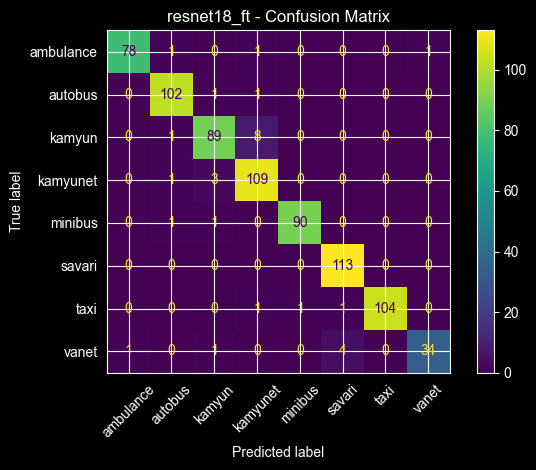

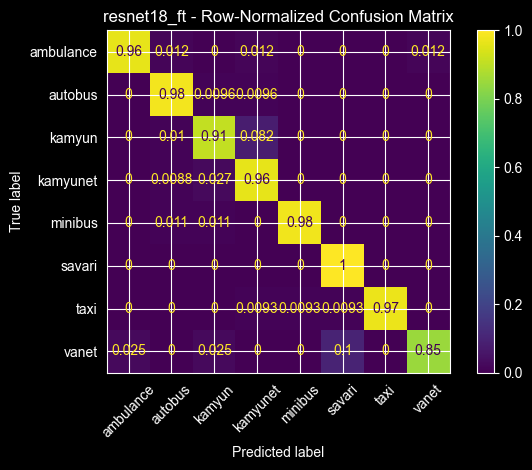

In [57]:
cm_res_ft , cm_res_normalized_ft = plot_confusion_matrices(
    y_true_res_ft,
    y_pred_res_ft,
    classes=classes,
    experiment_name="resnet18_ft",
    output_dir="../results/img",
)

In [58]:
targets, predictions, confidences, scores = extract_predictions_and_confidence(
    model=model_resnet_ft,
    loader=val_loader_resnet,
    device=device,
    loss_type="ce"
)
misclassified_indices = [
    i for i, (true_label, pred_label) in enumerate(zip(targets, predictions)) if true_label != pred_label
]
print(f"Total misclassified: {len(misclassified_indices)}")
for idx in misclassified_indices[:12]:
    image ,label = val_dataset_resnet[idx]
    print(
        f"Index: {idx} | "
        f"True: {val_dataset_resnet.classes[targets[idx]]} | "
        f"Pred: {val_dataset_resnet.classes[predictions[idx]]} | "
        f"Confidence: {confidences[idx]:.2%} | "
        f"Path: {val_dataset_resnet.samples[idx][0]}"
    )

Total misclassified: 29
Index: 0 | True: ambulance | Pred: vanet | Confidence: 95.26% | Path: ..\data\dataset\cleaned\val\ambulance\197398569.jpg
Index: 63 | True: ambulance | Pred: autobus | Confidence: 76.13% | Path: ..\data\dataset\cleaned\val\ambulance\218157597.jpg
Index: 66 | True: ambulance | Pred: kamyunet | Confidence: 99.49% | Path: ..\data\dataset\cleaned\val\ambulance\218335016.jpg
Index: 93 | True: autobus | Pred: kamyunet | Confidence: 89.65% | Path: ..\data\dataset\cleaned\val\autobus\205169590.jpg
Index: 118 | True: autobus | Pred: kamyun | Confidence: 91.00% | Path: ..\data\dataset\cleaned\val\autobus\215752917.jpg
Index: 191 | True: kamyun | Pred: kamyunet | Confidence: 99.86% | Path: ..\data\dataset\cleaned\val\kamyun\198119425.jpg
Index: 195 | True: kamyun | Pred: kamyunet | Confidence: 99.97% | Path: ..\data\dataset\cleaned\val\kamyun\199172201.jpg
Index: 199 | True: kamyun | Pred: kamyunet | Confidence: 68.91% | Path: ..\data\dataset\cleaned\val\kamyun\209037146.j

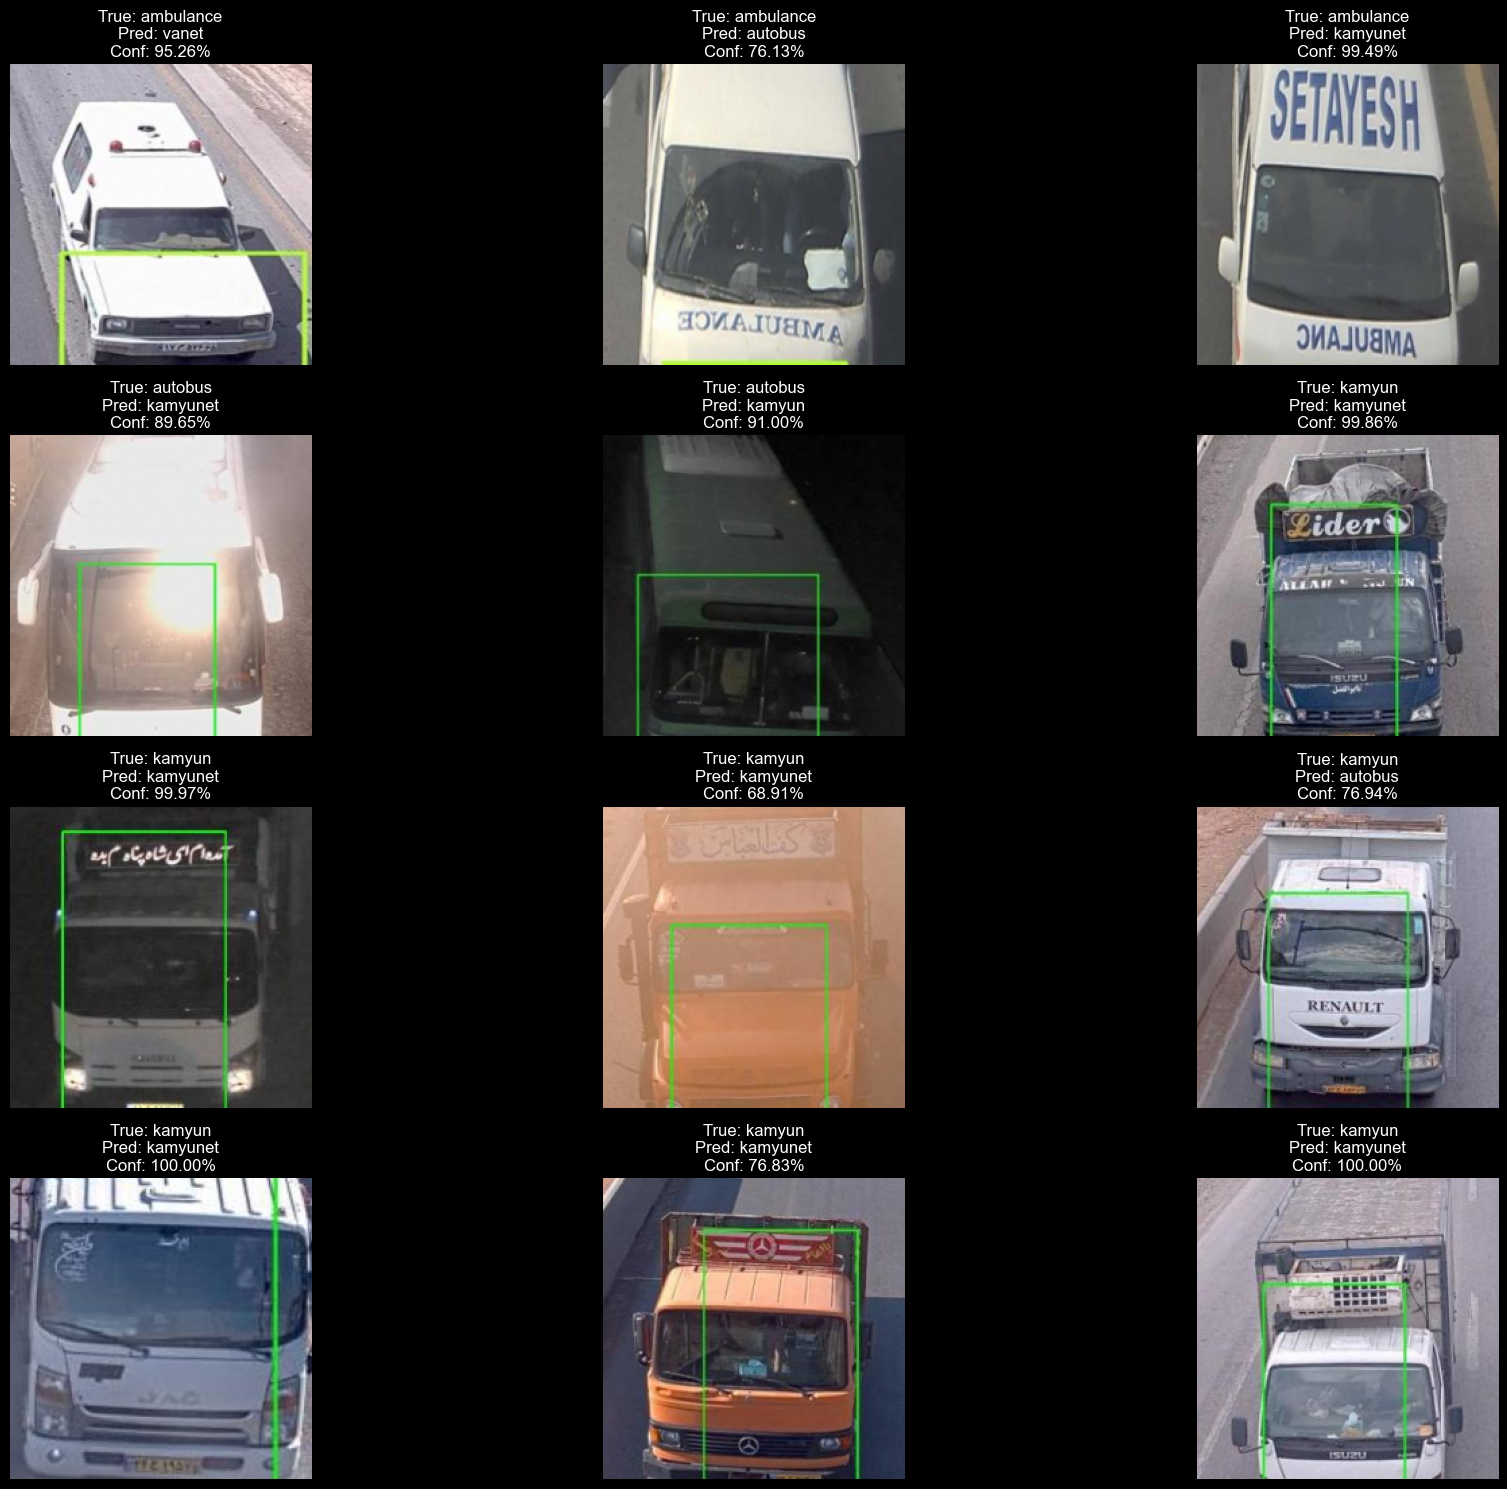

In [77]:
weights = ResNet18_Weights.DEFAULT
mean = torch.tensor(weights.transforms().mean).view(3, 1, 1)
std = torch.tensor(weights.transforms().std).view(3, 1, 1)

fig, axes = plt.subplots(4, 3, figsize=(20, 15))

for ax, idx in zip(axes.flat, misclassified_indices[:12]):

    image, _ = val_dataset_resnet[idx]
    image = image * std + mean
    image = image.clamp(0, 1)

    # CHW -> HWC
    image = image.permute(1, 2, 0)

    ax.imshow(image)
    ax.set_title(
        f"True: {val_dataset_resnet.classes[targets[idx]]}\n"
        f"Pred: {val_dataset_resnet.classes[predictions[idx]]}\n"
        f"Conf: {confidences[idx]:.2%}"
    )

    ax.axis("off")

plt.tight_layout()
plt.savefig(
    "../results/img/resnet_ft_misclassified_12.png",
    bbox_inches="tight",
    dpi=300,
    format="png",
)
plt.show()


#### Mutual Confusion

In [79]:
pair_confusions = []

for i in range(len(classes)):
    for j in range(i + 1, len(classes)):

        confusion_ij = cm_res_normalized_ft[i, j]
        confusion_ji = cm_res_normalized_ft[j, i]

        pair_confusion = confusion_ij + confusion_ji

        pair_confusions.append({
            "Class 1": classes[i],
            "Class 2": classes[j],
            "Class1 -> Class2": confusion_ij,
            "Class2 -> Class1": confusion_ji,
            "Mutual Confusion": pair_confusion
        })

pair_confusions_df = pd.DataFrame(pair_confusions)

pair_confusions_df = pair_confusions_df.sort_values(
    "Mutual Confusion",
    ascending=False
).reset_index(drop=True)

pair_confusions_df

,Class 1,Class 2,Class1 -> Class2,Class2 -> Class1,Mutual Confusion
0,kamyun,kamyunet,0.081633,0.026549,0.108181
1,savari,vanet,0.000000,0.100000,0.100000
2,ambulance,vanet,0.012346,0.025000,0.037346
3,kamyun,vanet,0.000000,0.025000,0.025000
4,autobus,kamyun,0.009615,0.010204,0.019819
5,autobus,kamyunet,0.009615,0.008850,0.018465
6,ambulance,kamyunet,0.012346,0.000000,0.012346
7,ambulance,autobus,0.012346,0.000000,0.012346
8,kamyun,minibus,0.000000,0.010870,0.010870
9,autobus,minibus,0.000000,0.010870,0.010870


#### check confidence and propose viewing by human operator

In [80]:
classes = val_loader_resnet.dataset.classes

results_df = pd.DataFrame({
    "true_label": [classes[i] for i in targets],
    "predicted_label": [classes[i] for i in predictions],
    "confidence": confidences,
})
results_df

,true_label,predicted_label,confidence
0,ambulance,vanet,0.952572
1,ambulance,ambulance,1.000000
2,ambulance,ambulance,1.000000
3,ambulance,ambulance,0.884684
4,ambulance,ambulance,0.999571
...,...,...,...
743,vanet,vanet,1.000000
744,vanet,savari,0.999832
745,vanet,ambulance,0.785434
746,vanet,savari,1.000000


In [81]:
thresholds = np.arange(0.70, 0.96, 0.05)
predictions = np.array(predictions)
targets = np.array(targets)
threshold_results = []
for threshold in thresholds:
    needs_review = confidences < threshold
    auto_accept = ~needs_review
    total = len(targets)
    review_count = needs_review.sum()
    auto_count = auto_accept.sum()
    # print(total, review_count, auto_count)
    review_rate = review_count / total
    coverage = auto_count / total
    overall_accuracy = np.mean(predictions == targets)

    if auto_count > 0:
        auto_accuracy = (
            predictions[auto_accept] == targets[auto_accept]
        ).mean()

        auto_errors = (
            predictions[auto_accept] != targets[auto_accept]
        ).sum()

        auto_error_rate = auto_errors / auto_count

    else:
        auto_accuracy = np.nan
        auto_errors = 0
        auto_error_rate = np.nan

    threshold_results.append({
        "threshold": threshold,
        "review_count": review_count,
        "review_rate": review_rate,
        "coverage": coverage,
        "auto_accuracy": auto_accuracy,
        "auto_error_rate": auto_error_rate,
    })


threshold_df = pd.DataFrame(threshold_results)
threshold_display = threshold_df.copy()

threshold_display["review_rate"] = (threshold_display["review_rate"] * 100).round(2)

threshold_display["coverage"] = (threshold_display["coverage"] * 100).round(2)

threshold_display["auto_accuracy"] = (threshold_display["auto_accuracy"] * 100).round(2)

threshold_display["auto_error_rate"] = (threshold_display["auto_error_rate"] * 100).round(2)

threshold_display

,threshold,review_count,review_rate,coverage,auto_accuracy,auto_error_rate
0,0.70,4,0.53,99.47,96.24,3.76
1,0.75,6,0.80,99.20,96.36,3.64
2,0.80,14,1.87,98.13,96.87,3.13
3,0.85,17,2.27,97.73,97.13,2.87
4,0.90,22,2.94,97.06,97.52,2.48
5,0.95,29,3.88,96.12,97.77,2.23


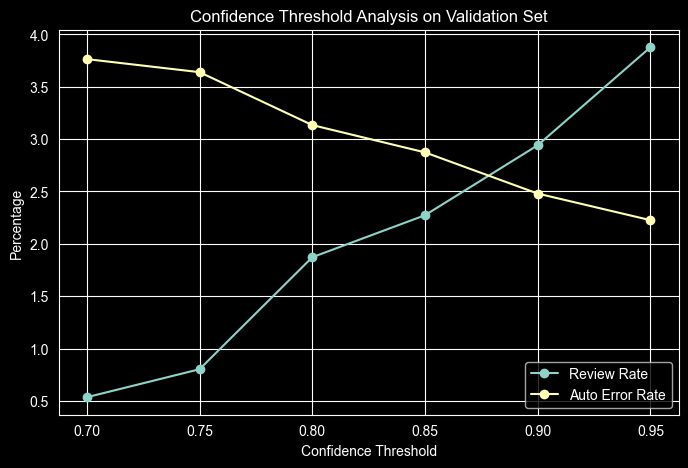

In [82]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df["threshold"],
    threshold_df["review_rate"] * 100,
    marker="o",
    label="Review Rate"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["auto_error_rate"] * 100,
    marker="o",
    label="Auto Error Rate"
)

plt.xlabel("Confidence Threshold")
plt.ylabel("Percentage")
plt.title("Confidence Threshold Analysis on Validation Set")
plt.legend()
plt.grid(True)
plt.savefig(
    "../results/img/resnet_ft_threshold_analysis.png",
    bbox_inches="tight",
    dpi=300,
)
plt.show()

In [83]:
threshold_error_results = []

for threshold in thresholds:
    auto_accept = confidences >= threshold

    auto_count = auto_accept.sum()

    wrong_auto = (
        (predictions != targets) &
        auto_accept
    )

    wrong_auto_count = wrong_auto.sum()

    threshold_error_results.append({
        "threshold": threshold,
        "auto_count": auto_count,
        "wrong_auto_count": wrong_auto_count,
        "wrong_auto_rate": (
            wrong_auto_count / auto_count * 100
            if auto_count > 0 else np.nan
        )
    })

threshold_error_df = pd.DataFrame(threshold_error_results)

print(threshold_error_df)

   threshold  auto_count  wrong_auto_count  wrong_auto_rate
0       0.70         744                28         3.763441
1       0.75         742                27         3.638814
2       0.80         734                23         3.133515
3       0.85         731                21         2.872777
4       0.90         726                18         2.479339
5       0.95         719                16         2.225313


In [84]:
wrong_predictions_df = results_df[
    results_df["true_label"] != results_df["predicted_label"]
].sort_values(
    by="confidence",
    ascending=False
)
print(wrong_predictions_df)

    true_label predicted_label  confidence
243     kamyun        kamyunet    1.000000
269     kamyun        kamyunet    1.000000
228     kamyun        kamyunet    1.000000
746      vanet          savari    1.000000
279     kamyun        kamyunet    1.000000
729      vanet          savari    0.999997
309   kamyunet          kamyun    0.999978
744      vanet          savari    0.999832
195     kamyun        kamyunet    0.999727
638       taxi          savari    0.999025
468    minibus         autobus    0.998867
191     kamyun        kamyunet    0.998641
662       taxi         minibus    0.995513
66   ambulance        kamyunet    0.994941
387   kamyunet         autobus    0.994688
0    ambulance           vanet    0.952572
398    minibus          kamyun    0.937534
118    autobus          kamyun    0.909987
93     autobus        kamyunet    0.896505
739      vanet          kamyun    0.855596
696       taxi        kamyunet    0.855217
346   kamyunet          kamyun    0.821538
305   kamyu

In [85]:
threshold_df[
    [
        "threshold",
        "coverage",
        "review_rate",
        "auto_accuracy",
        "auto_error_rate"
    ]
].round(2)

,threshold,coverage,review_rate,auto_accuracy,auto_error_rate
0,0.70,0.99,0.01,0.96,0.04
1,0.75,0.99,0.01,0.96,0.04
2,0.80,0.98,0.02,0.97,0.03
3,0.85,0.98,0.02,0.97,0.03
4,0.90,0.97,0.03,0.98,0.02
5,0.95,0.96,0.04,0.98,0.02
